## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [ ]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

50.0

In [12]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [13]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


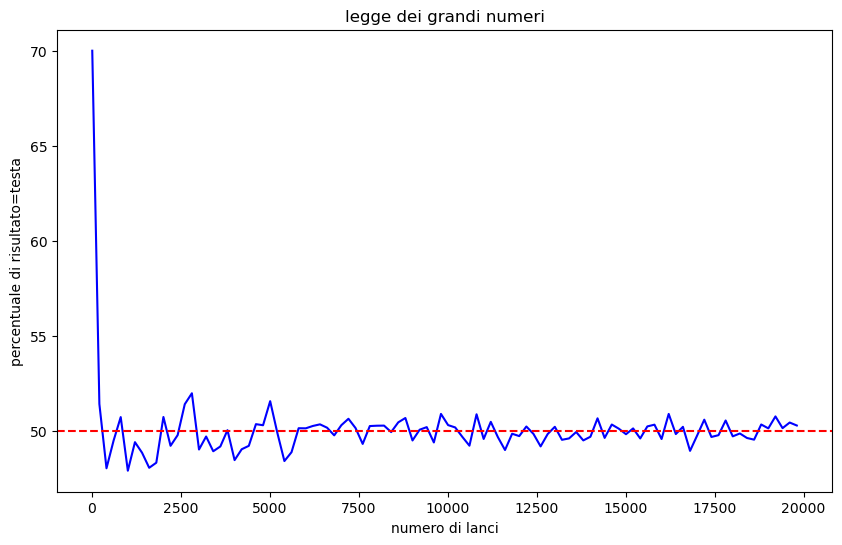

In [15]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
numeroRighe = len(df)
numeroColone = len(df.columns)
print(f"Ci sono {numeroRighe} righe e {numeroColone} colonne")


Ci sono 891 righe e 12 colonne


In [5]:
colonne= df.columns
for i in colonne:
    lun = df[i].isna().sum()
    print(f"{i} ha {lun} elementi nulli")




PassengerId ha 0 elementi nulli
Survived ha 0 elementi nulli
Pclass ha 0 elementi nulli
Name ha 0 elementi nulli
Sex ha 0 elementi nulli
Age ha 177 elementi nulli
SibSp ha 0 elementi nulli
Parch ha 0 elementi nulli
Ticket ha 0 elementi nulli
Fare ha 0 elementi nulli
Cabin ha 687 elementi nulli
Embarked ha 2 elementi nulli


In [6]:
moda = df['Embarked'].mode()[0]
df.Embarked = df.Embarked.fillna(moda)

In [7]:
righeDuplicate = df.duplicated(keep="first").sum()
if(righeDuplicate == 0):
    print("Non ci sono righe duplicate")
else:
    print(f"Ci sono {righeDuplicate} righe duplicate")


Non ci sono righe duplicate


In [8]:
mediaEta = df.groupby("Pclass")['Age'].mean()


for i in mediaEta.index:
    df.loc[df['Pclass'] == i, "Age"] = df[df['Pclass'] == i]['Age'].fillna(mediaEta.loc[i])



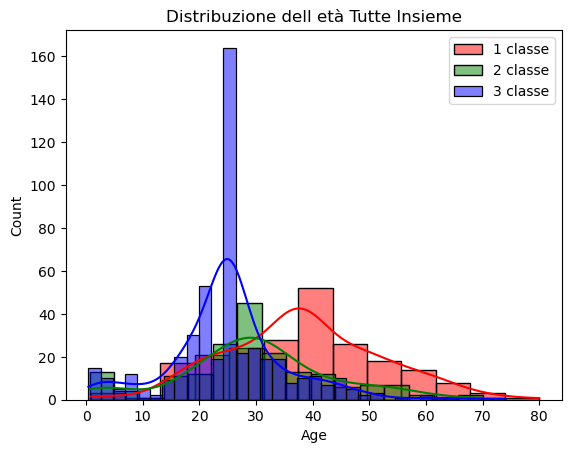

In [26]:
sns.histplot(data=df[df['Pclass'] == 1], x='Age', label="1 classe", kde=True, color = "red",)
sns.histplot(data=df[df['Pclass'] == 2], x='Age', label="2 classe",kde=True, color = "green")
sns.histplot(data=df[df['Pclass'] == 3], x='Age', label="3 classe",kde=True, color = "blue")
plt.title('Distribuzione dell età Tutte Insieme')
plt.legend()
plt.show()

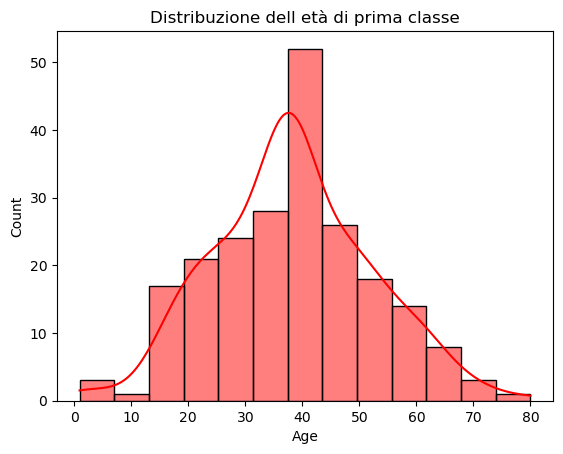

In [21]:
sns.histplot(data=df[df['Pclass'] == 1], x='Age', kde=True, color = "red",)
plt.title('Distribuzione dell età di prima classe')
plt.show()

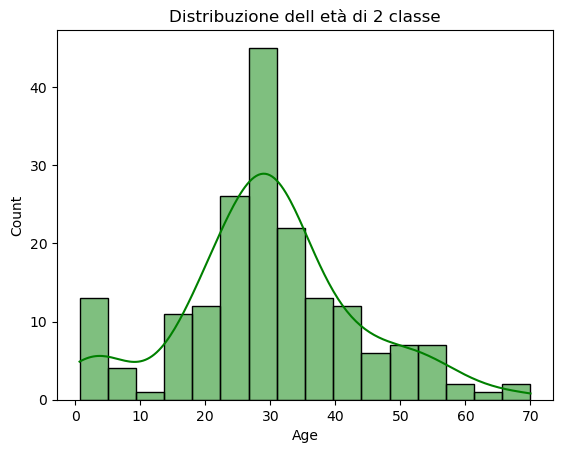

In [22]:
sns.histplot(data=df[df['Pclass'] == 2], x='Age', kde=True, color = "green")
plt.title('Distribuzione dell età di 2 classe')
plt.show()

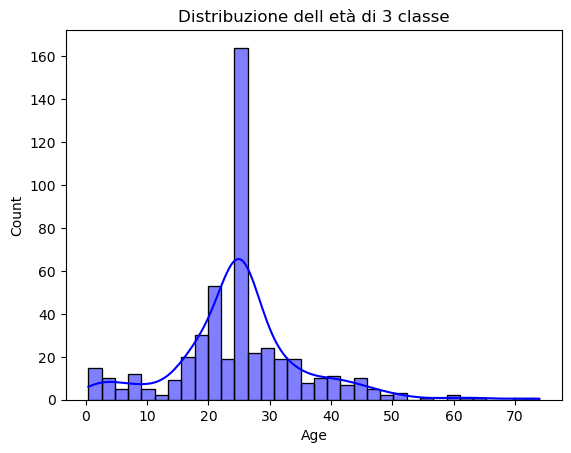

In [23]:
sns.histplot(data=df[df['Pclass'] == 3], x='Age', kde=True, color = "blue")
plt.title('Distribuzione dell età di 3 classe')
plt.show()

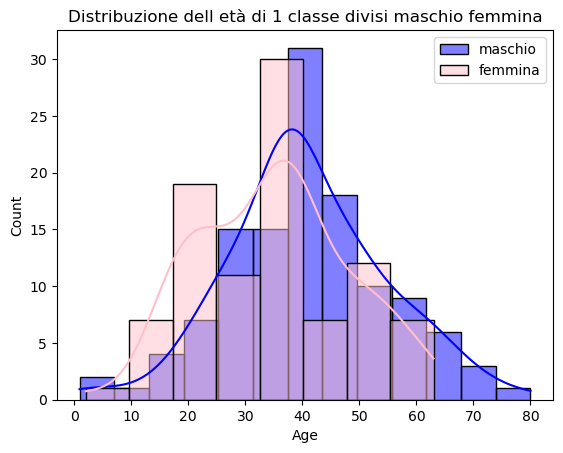

In [29]:
sns.histplot(data=df[(df['Pclass'] == 1) & (df['Sex'] == "male")], x='Age',label = "maschio", kde=True, color = "blue")
sns.histplot(data=df[(df['Pclass'] == 1) & (df['Sex'] == "female")], x='Age',label = "femmina", kde=True, color = "pink")
plt.title('Distribuzione dell età di 1 classe divisi maschio femmina')
plt.legend()
plt.show()

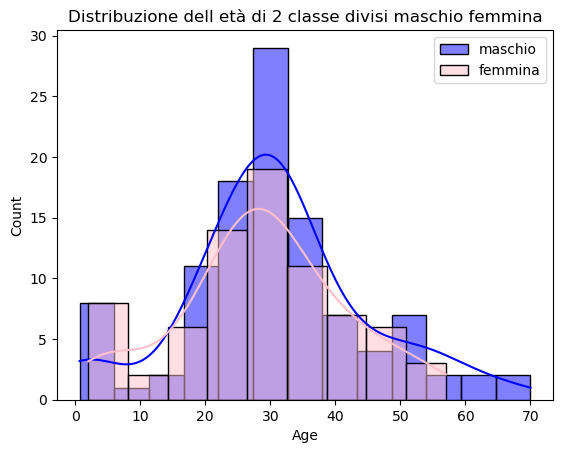

In [28]:
sns.histplot(data=df[(df['Pclass'] == 2) & (df['Sex'] == "male")], x='Age',label = "maschio", kde=True, color = "blue")
sns.histplot(data=df[(df['Pclass'] == 2) & (df['Sex'] == "female")], x='Age',label = "femmina", kde=True, color = "pink")
plt.title('Distribuzione dell età di 2 classe divisi maschio femmina')
plt.legend()
plt.show()

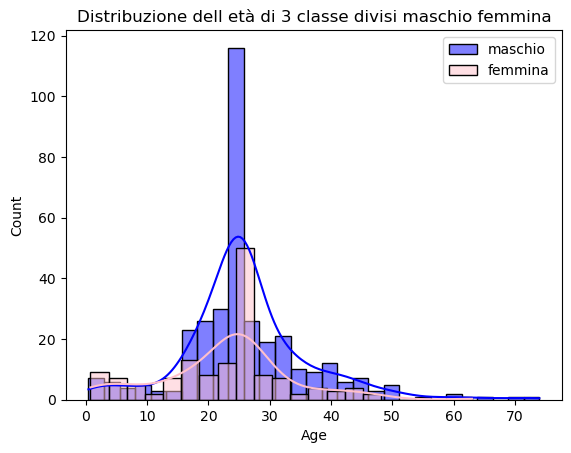

In [27]:
sns.histplot(data=df[(df['Pclass'] == 3) & (df['Sex'] == "male")], x='Age',label = "maschio", kde=True, color = "blue")
sns.histplot(data=df[(df['Pclass'] == 3) & (df['Sex'] == "female")], x='Age',label = "femmina", kde=True, color = "pink")
plt.title('Distribuzione dell età di 3 classe divisi maschio femmina')
plt.legend()
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.groupby("species").agg({
    "species":["size"],
    "petal_length":["mean"],
    "petal_width":["mean"]
})


,species,petal_length,petal_width
,size,mean,mean
species,,,
setosa,50,1.462,0.246
versicolor,50,4.260,1.326
virginica,50,5.552,2.026


setosa
versicolor
virginica


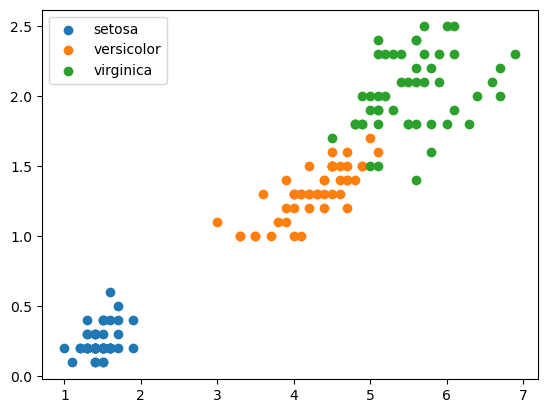

In [50]:
diverseSpecie = df["species"].unique()
for i in diverseSpecie:
    plt.scatter(df[df["species"] == i]['petal_length'],df[df["species"] == i]['petal_width'],label=i)
plt.legend()
plt.show()

In [52]:
df["petal_area"] = df["petal_length"] * df["petal_width"]
df["petal_area"].describe()

count    150.000000
mean       5.794067
std        4.712390
min        0.110000
25%        0.420000
50%        5.615000
75%        9.690000
max       15.870000
Name: petal_area, dtype: float64

In [ ]:
sns.boxplot(data=df, x='species', y='petal_area')
plt.title('Lunghezza del becco per specie')
plt.show()